In [27]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

import pandas as pd

In [28]:
insurenceData = pd.read_csv("/content/insurance.csv")

X = insurenceData.drop(columns=["charges"])
y = insurenceData["charges"]

X = pd.get_dummies(X, columns=["region"], drop_first=True, dtype=int)
X["sex"] = X["sex"].map({'male': 0, 'female': 0})
X["smoker"] = X["smoker"].map({'yes': 1, 'no': 0})

X["age_smoker"] = X["age"] * X["smoker"]
X["bmi_smoker"] = X["bmi"] * X["smoker"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

mse for alpha=0.01 is :  20961550.69734877
mse for alpha=0.1 is :  20960941.07509178
mse for alpha=1 is :  20955089.140838325
mse for alpha=2 is :  20949666.42577437
mse for alpha=5 is :  20935572.14682204
mse for alpha=10 is :  20922302.161065746
mse for alpha=20 is :  20934071.3380266
mse for alpha=30 is :  20996906.241700586
mse for alpha=40 is :  21105920.313233253
mse for alpha=50 is :  21252795.109016832
mse for alpha=100 is :  22423174.20702652


<Axes: >

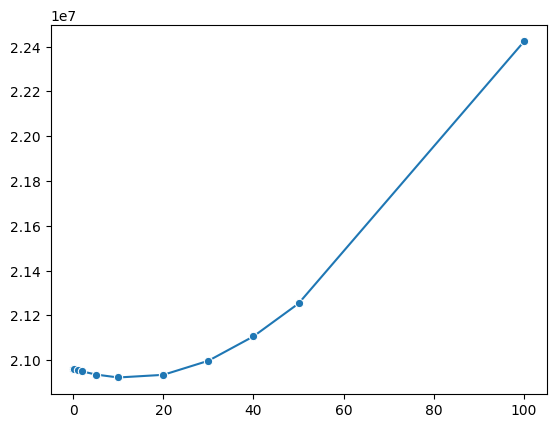

In [32]:
import seaborn as sns

alphas = [0.001, 0.1, 1, 2, 5, 10, 20, 30, 40, 50, 100]
mseVal = []

for a in alphas:
  lassoModel = Lasso(alpha=a)
  lassoModel.fit(X_train, y_train)

  y_predict = lassoModel.predict(X_test)
  mse = mean_squared_error(y_test, y_predict)
  print(f"mse for alpha={a} is : ", mse)
  mseVal.append(mse)

# we have to perform hidden trial to check many lamda or alpha vlaues

sns.lineplot(x=alphas, y=mseVal, marker="o")

In [ ]:
# from the plot we can see the value of alpha should be small in between 0 - 20 here the mse is less

In [37]:
from sklearn.linear_model import LassoCV
al = [0.001, 0.1, 1, 2, 5, 10, 20, 30, 40, 50, 100]

lasso_cv_model = LassoCV(
    alphas = al,
    cv = 5,
    max_iter = 1000,
    random_state = 42
)

lasso_cv_model.fit(X_train, y_train)
print("best alpha value: ", lasso_cv_model.alpha_)

y_pred = lasso_cv_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("mse: ", mse)

r2 = r2_score(y_test, y_pred)
print("r2: ", r2)

best alpha value:  0.1
mse:  20960941.07509178
r2:  0.864984783619939
